In [3]:
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wave
import pylab
import itertools
import librosa 
import librosa.display as ld
from tensorflow.keras import layers, models, callbacks
from keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from scipy import signal
from scipy.io import wavfile
# Download latest version
path = kagglehub.dataset_download("warcoder/cats-vs-dogs-vs-birds-audio-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\warcoder\cats-vs-dogs-vs-birds-audio-classification\versions\1


In [4]:
file = os.listdir(path)
files_in_dir = os.listdir(path + '/' + file[0])

print(files_in_dir)

path_to_files = path + '/' + file[0]

['bird', 'cat', 'dog']


In [5]:
import os
import pandas as pd
from pathlib import Path

path = r'C:\Users\user\.cache\kagglehub\datasets\warcoder\cats-vs-dogs-vs-birds-audio-classification\versions\1'
animals_path = os.path.join(path, 'Animals')


audio_data = []
audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']

for class_name in ['bird', 'cat', 'dog']:
    class_path = os.path.join(animals_path, class_name)
    if os.path.exists(class_path):
        for file in os.listdir(class_path):
            file_path = os.path.join(class_path, file)
            if os.path.isfile(file_path):
                file_size = os.path.getsize(file_path) / 1024  # KB
                audio_data.append({
                    'class': class_name,
                    'filename': file,
                    'path': file_path,
                    'size_kb': round(file_size, 2)
                })

df = pd.DataFrame(audio_data)
print(f"Всего аудио файлов: {len(df)}")
print(f"Распределение по классам:")
print(df['class'].value_counts())
df

Всего аудио файлов: 610
Распределение по классам:
class
dog     210
cat     207
bird    193
Name: count, dtype: int64


,class,filename,path,size_kb
0,bird,00b01445_nohash_0.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
1,bird,00f0204f_nohash_1.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
2,bird,00f0204f_nohash_3.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
3,bird,01648c51_nohash_0.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
4,bird,01bcfc0c_nohash_1.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
...,...,...,...,...
605,dog,fb7cfe0e_nohash_2.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
606,dog,fbf3dd31_nohash_0.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,30.71
607,dog,fc28c8d8_nohash_0.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29
608,dog,fda46b78_nohash_0.wav,C:\Users\user\.cache\kagglehub\datasets\warcod...,31.29


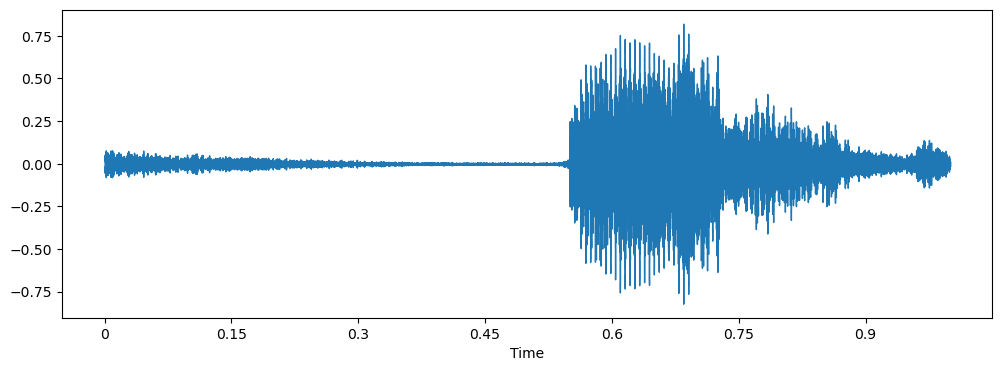

In [6]:
for subdir in [files_in_dir[0]]:
    subdir_path = os.path.join(path_to_files, subdir)
    wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]

    for i in range(1):
        file_path = os.path.join(subdir_path, wav_files[i])
        signal, sr = librosa.load(file_path, sr = 22050)

        plt.figure(figsize=(12,4))
        ld.waveshow(signal, sr=sr)
        plt.show()

In [7]:
import IPython
display(IPython.display.Audio(signal, rate = sr))

Text(0, 0.5, 'Amplitude')

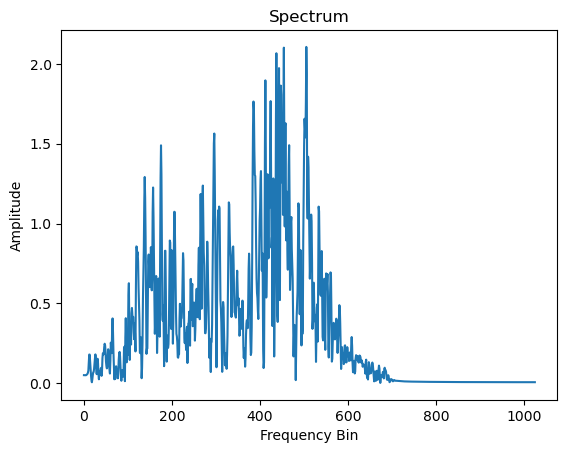

In [8]:
n_fft = 2048
ft = np.abs(librosa.stft(signal[:n_fft], hop_length = n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')

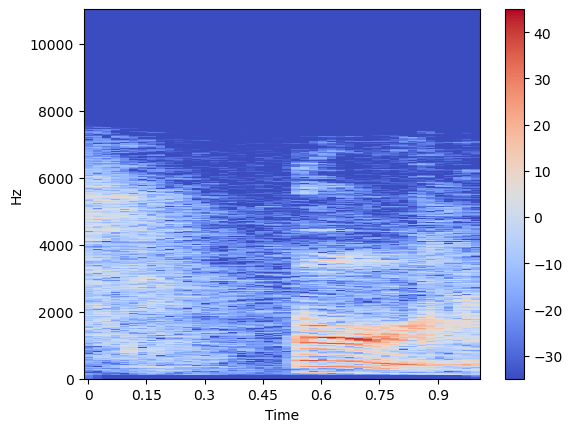

In [9]:
X = librosa.stft(signal)
s = librosa.amplitude_to_db(abs(X))
ld.specshow(s, sr=sr, x_axis = 'time', y_axis='linear')
plt.colorbar()

In [10]:
mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc = 40, hop_length=512)
mfccs

array([[-2.69054474e+02, -2.45100143e+02, -2.49817581e+02, ...,
        -2.37508850e+02, -2.29305054e+02, -2.52596375e+02],
       [-1.41957998e-02,  8.44315434e+00,  1.48652325e+01, ...,
         1.11352722e+02,  1.17785675e+02,  1.22704529e+02],
       [-9.63383179e+01, -1.04654846e+02, -1.04088089e+02, ...,
        -9.98371124e+01, -1.03090973e+02, -8.81853714e+01],
       ...,
       [-1.02745962e+00, -8.41684937e-01,  2.68875885e+00, ...,
        -4.19203138e+00, -9.36969876e-01,  1.61677337e+00],
       [ 1.58495474e+00,  9.44116116e-01, -5.33202529e-01, ...,
        -1.12263889e+01, -8.74185944e+00, -2.82874322e+00],
       [ 3.40143347e+00,  1.20849490e+00, -6.06596470e+00, ...,
        -2.48521686e+00, -5.64353466e+00, -3.41440511e+00]], dtype=float32)

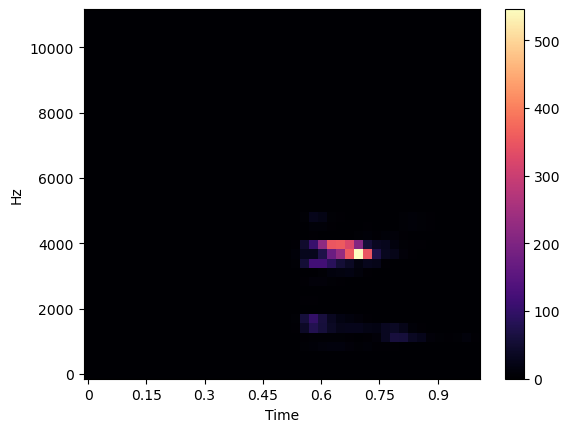

In [11]:
melspectrum = librosa.feature.melspectrogram(y=signal, sr = sr,hop_length =512, n_mels = 40)
ld.specshow(melspectrum, sr=sr, x_axis = 'time', y_axis='linear')
plt.colorbar()

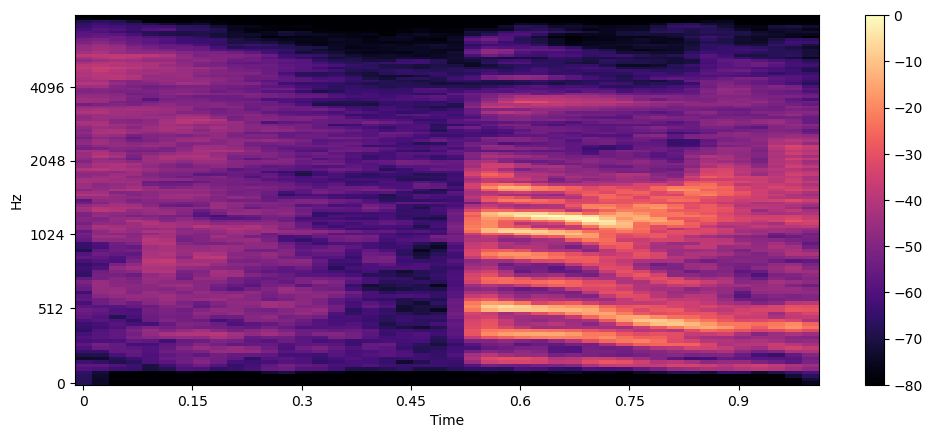

In [12]:
S = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure().set_figwidth(12)
librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sr, fmax=8000)
plt.colorbar()

In [13]:
data = []
labels = []

for k, subdir in enumerate(files_in_dir):
    subdir_path = os.path.join(path_to_files, subdir)
    wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]

    for i in range(len(wav_files)):
        file_path = os.path.join(subdir_path, wav_files[i])
        signal, sr = librosa.load(file_path, sr = 10000)
        dorojka = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc = 40, hop_length=512)
        data.append(np.mean(dorojka, axis = 1))
        labels.append(k)
data = np.array(data)
labels = np.array(labels)
from sklearn.model_selection import train_test_split

X = data
y = labels

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=True, stratify=y)
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_leaf=5)
clf.fit(x_train, y_train)


RandomForestClassifier(max_depth=20, min_samples_leaf=5)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib


y_pred_train = clf.predict(x_train)
y_pred_test = clf.predict(x_test)


print(f'Точность на обучающей выборке: {accuracy_score(y_train, y_pred_train):.3f}')
print(f'Точность на тестовой выборке: {accuracy_score(y_test, y_pred_test):.3f}')
print(f'Разница (переобучение): {accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test):.3f}')

Точность на обучающей выборке: 0.986
Точность на тестовой выборке: 0.750
Разница (переобучение): 0.236


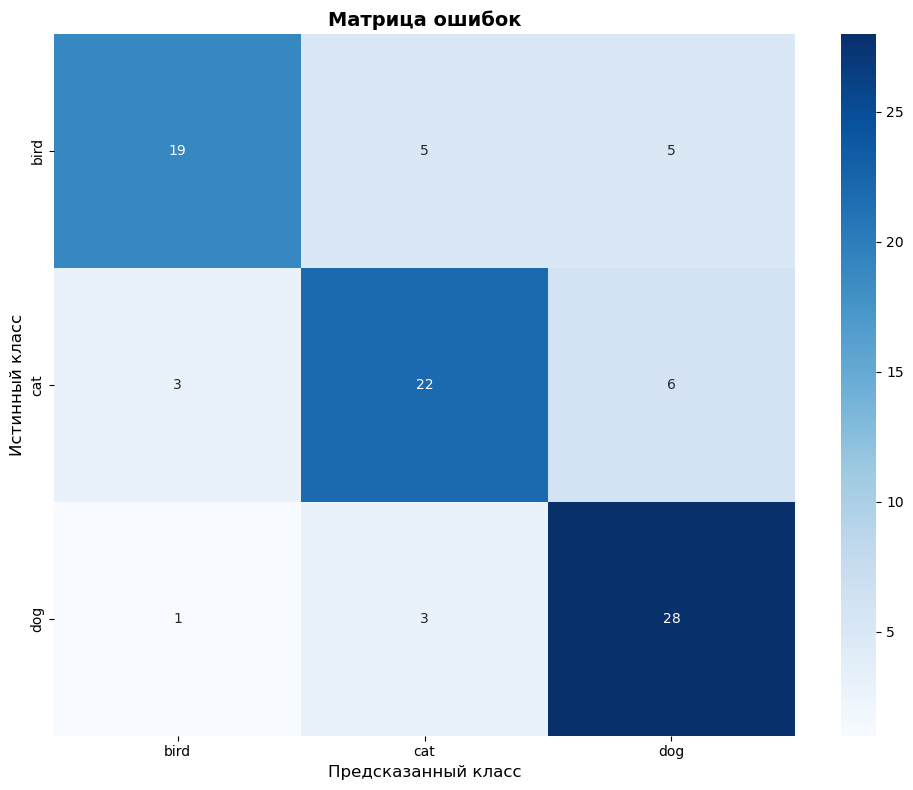

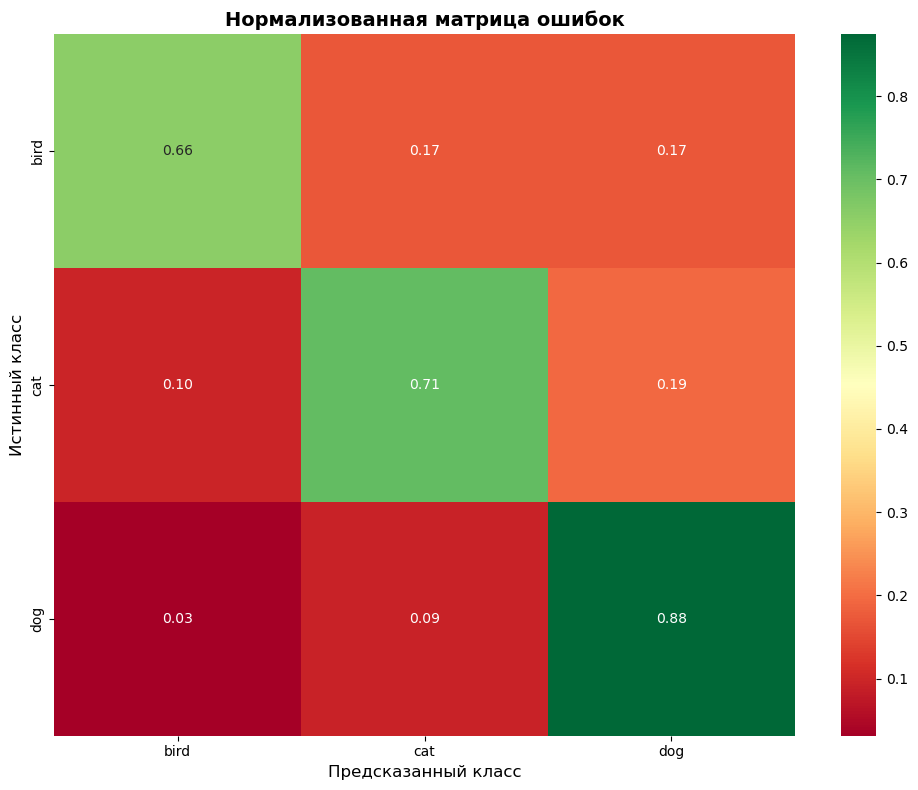

In [21]:
import seaborn as sns
class_names = [os.path.basename(subdir) for subdir in files_in_dir]

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Матрица ошибок', fontsize=14, fontweight='bold')  
plt.xlabel('Предсказанный класс', fontsize=12)  
plt.ylabel('Истинный класс', fontsize=12)  
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Нормализованная матрица ошибок', fontsize=14, fontweight='bold')  
plt.xlabel('Предсказанный класс', fontsize=12)  
plt.ylabel('Истинный класс', fontsize=12) 
plt.tight_layout()
plt.show()


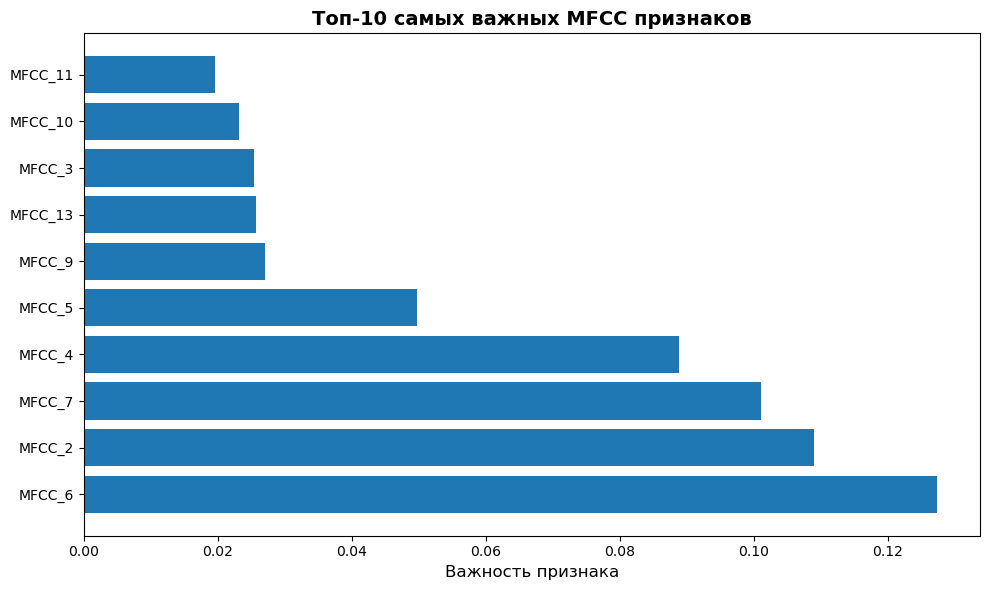

In [22]:
feature_importance = clf.feature_importances_
feature_names = [f'MFCC_{i+1}' for i in range(len(feature_importance))]

top_n = 10
top_indices = np.argsort(feature_importance)[-top_n:]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feature_importance[top_indices])
plt.yticks(range(top_n), [feature_names[i] for i in top_indices])
plt.xlabel('Важность признака', fontsize=12)
plt.title(f'Топ-{top_n} самых важных MFCC признаков', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
pip install audiomentations


  Attempting uninstall: soxr

    Found existing installation: soxr 1.0.0

    Uninstalling soxr-1.0.0:

      Successfully uninstalled soxr-1.0.0

   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   ---------------------------------------- 0/5 [soxr]
   -----------------------

  You can safely remove it manually.


In [26]:
from audiomentations import (
    Compose,
    AddGaussianNoise,
    TimeStretch,
    PitchShift,
    Shift,
    Reverse,
    AddGaussianSNR,
    ClippingDistortion,
    BandPassFilter,
    Gain
)
train_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),  # Изменение скорости
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),  # Изменение высоты тона
    Shift(min_shift=-0.2, max_shift=0.2, p=0.5),  # ✅ Исправлено: min_shift и max_shift вместо min_fraction/max_fraction
    AddGaussianSNR(min_snr_db=5, max_snr_db=40, p=0.3),  # Добавление шума с заданным SNR
    Gain(min_gain_db=-12, max_gain_db=12, p=0.3),  # Изменение громкости
], p=1.0)

def load_and_augment_data(path_to_files, files_in_dir, use_augmentation=True, augmentation_factor=2):
    data = []
    labels = []
    
    for k, subdir in enumerate(files_in_dir):
        subdir_path = os.path.join(path_to_files, subdir)
        wav_files = [file for file in os.listdir(subdir_path) if file.endswith('.wav')]
        
        print(f"Обработка класса {k}: {subdir} (файлов: {len(wav_files)})")
        
        for i in range(len(wav_files)):
            file_path = os.path.join(subdir_path, wav_files[i])
            signal, sr = librosa.load(file_path, sr=10000)
            
            dorojka = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40, hop_length=512)
            data.append(np.mean(dorojka, axis=1))
            labels.append(k)
            
            if use_augmentation:
                for aug_idx in range(augmentation_factor - 1):
                    try:
                        augmented_signal = train_augmentations(samples=signal, sample_rate=sr)
                        
                        
                        dorojka_aug = librosa.feature.mfcc(y=augmented_signal, sr=sr, n_mfcc=40, hop_length=512)
                        data.append(np.mean(dorojka_aug, axis=1))
                        labels.append(k)
                    except Exception as e:
                        print(f"Ошибка аугментации файла {wav_files[i]}: {e}")
                        continue
        
        print(f"Создано сэмплов: {len([l for l in labels if l == k])}")
    
    return np.array(data), np.array(labels)

In [29]:
data, labels = load_and_augment_data(
    path_to_files, 
    files_in_dir, 
    use_augmentation=True, 
    augmentation_factor=3  # 1 оригинал + 2 аугментированные копии
)

print(f"Всего сэмплов после аугментации: {len(data)}")
print(f"Количество классов: {len(np.unique(labels))}")

X = data
y = labels


x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=True, stratify=y, random_state=42
)

print(f"Размер обучающей выборки: {len(x_train)}")
print(f"Размер тестовой выборки: {len(x_test)}")

Обработка класса 0: bird (файлов: 193)
  Создано сэмплов: 579
Обработка класса 1: cat (файлов: 207)
  Создано сэмплов: 621
Обработка класса 2: dog (файлов: 210)
  Создано сэмплов: 630
Всего сэмплов после аугментации: 1830
Количество классов: 3
Размер обучающей выборки: 1555
Размер тестовой выборки: 275


In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [34]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

clf.fit(x_train_scaled, y_train)

train_acc = accuracy_score(y_train, clf.predict(x_train_scaled))
test_acc = accuracy_score(y_test, clf.predict(x_test_scaled))

print(f"\nТочность на обучающей выборке: {train_acc:.3f}")
print(f"Точность на тестовой выборке: {test_acc:.3f}")
print(f"Разница: {train_acc - test_acc:.3f}")


joblib.dump(clf, 'audio_classifier_augmented.pkl')
joblib.dump(scaler, 'scaler.pkl')


class_names = [os.path.basename(subdir) for subdir in files_in_dir]
metadata = {
    'class_names': class_names,
    'n_mfcc': 40,
    'sampling_rate': 10000,
    'hop_length': 512
}
joblib.dump(metadata, 'model_metadata.pkl')


Точность на обучающей выборке: 0.983
Точность на тестовой выборке: 0.836
Разница: 0.147


['model_metadata.pkl']